<a href="https://colab.research.google.com/github/obeabi/ProjectPortfolio/blob/master/SP500_Sector_Stages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade yfinance
!pip install  --upgrade pandas_ta
!pip install ta pandas_ta

In [2]:
import yfinance as yf
print(yf.__version__)
import pandas as pd
import numpy as np
import time
import ta
import requests
from datetime import datetime, timedelta
import numpy as np
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries Installed!")

0.2.66
Libraries Installed!


In [3]:

# ETF universe
etfs = ["XLF", "XLK", "XLV", "XLE", "XLY", "XLP", "XLI", "XLU", "XLRE", "XLC","SMH","SOXX","TQQQ","SDS","USO","GBTC","QQQ","TLT","TBT",'MAGS']

# Benchmark
benchmark = yf.download("SPY", period="6mo", interval="1wk", auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


# Classify Sector Stages

In [4]:

def weinstein_stage(df, sma_window=30):
    """Determine Weinstein stage using 30-week SMA and its slope."""
     # Handle MultiIndex columns
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df["SMA"] = df["Close"].rolling(window=sma_window).mean()

    # Compute linear regression slope on last N SMA points
    if len(df.dropna()) < sma_window:
        return None  # not enough data

    slope, _, _, _, _ = linregress(range(sma_window), df["SMA"].tail(sma_window))

    latest_price = df["Close"].iloc[-1]
    latest_sma = df["SMA"].iloc[-1]

    # Determine stage
    if latest_price > latest_sma and slope > 0:
        stage = "Stage 2 (Advancing)"
    elif latest_price < latest_sma and slope < 0:
        stage = "Stage 4 (Declining)"
    elif latest_price < latest_sma and slope > 0:
        stage = "Stage 1 (Basing)"
    elif latest_price > latest_sma and slope < 0:
        stage = "Stage 3 (Topping)"
    else:
        stage = "Transition"

    return stage, slope, latest_price, latest_sma


In [5]:

results = []
for etf in etfs:
    df = yf.download(etf, period="3y", interval="1wk", auto_adjust=True)
    stage_info = weinstein_stage(df)
    if stage_info:
        stage, slope, price, sma = stage_info
        results.append({
            "ETF": etf,
            "Stage": stage,
            "SMA_Slope": slope,
            "Latest_Price": price,
            "30W_SMA": sma
        })

stages_df = pd.DataFrame(results).sort_values(by="SMA_Slope", ascending=False)
stages_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,ETF,Stage,SMA_Slope,Latest_Price,30W_SMA
16,QQQ,Stage 2 (Advancing),1.403313,611.539978,542.708298
10,SMH,Stage 2 (Advancing),1.051411,347.220001,273.140999
1,XLK,Stage 2 (Advancing),0.715661,288.190002,248.063492
11,SOXX,Stage 2 (Advancing),0.530860,292.970001,231.414114
15,GBTC,Stage 2 (Advancing),0.513998,86.889999,84.663667
6,XLI,Stage 2 (Advancing),0.387305,153.520004,144.400720
9,XLC,Stage 2 (Advancing),0.343098,116.239998,105.702741
7,XLU,Stage 2 (Advancing),0.196709,91.540001,82.625819
19,MAGS,Stage 2 (Advancing),0.144691,65.290001,55.858000
4,XLY,Stage 2 (Advancing),0.135827,236.279999,218.489664


In [6]:

def compute_mansfield_rs(asset_df, benchmark_df, window):
    """Compute Mansfield Relative Strength (MRS) vs a benchmark."""
    # Handle MultiIndex columns
    if isinstance(asset_df.columns, pd.MultiIndex):
        asset_df.columns = asset_df.columns.get_level_values(0)
    if isinstance(benchmark_df.columns, pd.MultiIndex):
        benchmark_df.columns = benchmark_df.columns.get_level_values(0)

    # Align and clean data
    data = pd.DataFrame({
        "Asset": asset_df["Close"],
        "Benchmark": benchmark_df["Close"]
    }).reindex(asset_df.index.union(benchmark_df.index)).ffill().dropna()

    if len(data) < window:
        return None  # not enough data

    data["RS"] = data["Asset"] / data["Benchmark"]
    data["RS_MA"] = data["RS"].rolling(window=window, min_periods=window).mean()
    data["MRS"] = ((data["RS"] / data["RS_MA"]) - 1) * 100

    return data["MRS"].iloc[-1]  # latest MRS value


In [7]:
# ---------- STAGE 1: 3-MONTH MRS (12 weeks) ----------
mrs_3m = {}
for etf in etfs:
    data = yf.download(etf, period="6mo", interval="1wk", auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=12)
    if mrs_value is not None:
        mrs_3m[etf] = mrs_value

mrs_3m_df = pd.DataFrame(list(mrs_3m.items()), columns=["ETF", "MRS_3M"])
mrs_3m_df = mrs_3m_df[mrs_3m_df["MRS_3M"] > 0].sort_values(by="MRS_3M", ascending=False)
print("\n✅ 3-Month Positive MRS ETFs:")
mrs_3m_df.reset_index(drop=True)
mrs_3m_df


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********


✅ 3-Month Positive MRS ETFs:


,ETF,MRS_3M
11,SOXX,8.708025
10,SMH,8.007358
12,TQQQ,7.780623
7,XLU,2.835305
1,XLK,2.676462
2,XLV,1.913095
19,MAGS,1.703990
16,QQQ,1.326572
17,TLT,0.750064


In [13]:
# ---------- STAGE 2: 1-MONTH MRS (4 weeks) ----------
selected_etfs = mrs_3m_df["ETF"].tolist()
mrs_1m = {}
for etf in selected_etfs:
    data = yf.download(etf, period="3mo", interval="1wk",auto_adjust=True)
    mrs_value = compute_mansfield_rs(data, benchmark, window=4)
    if mrs_value is not None:
        mrs_1m[etf] = mrs_value

mrs_1m_df = pd.DataFrame(list(mrs_1m.items()), columns=["ETF", "MRS_1M"]).sort_values(by="MRS_1M", ascending=False)
mrs_1m_df = mrs_1m_df[mrs_1m_df["MRS_1M"] > 0].sort_values(by="MRS_1M", ascending=False)
print("\n🔥 1-Month MRS Ranking Among 3M Positive ETFs:")
mrs_1m_df.reset_index(drop=True)
mrs_1m_df

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


🔥 1-Month MRS Ranking Among 3M Positive ETFs:


,ETF,MRS_1M
2,TQQQ,3.299425
0,SOXX,2.385581
1,SMH,1.690279
6,MAGS,0.652120
7,QQQ,0.548466
4,XLK,0.418447
3,XLU,0.050549


In [14]:

def get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66, period="3mo", interval="1d"):
    """
    Filters a ranked list of tickers to return only uncorrelated picks.

    Parameters:
    -----------
    tickers : list
        All candidate tickers.
    ranked_picks : list
        Ranked list of tickers (best to worst).
    threshold : float
        Correlation threshold (default 0.66).
    period : str
        Data period for yfinance (default "3mo").
    interval : str
        Data interval (default "1d").

    Returns:
    --------
    final_selection : list
        List of uncorrelated tickers.
    corr_matrix : DataFrame
        Correlation matrix of daily returns.
    """
    # Step 1: Get prices
    data = yf.download(tickers, period=period, interval=interval,auto_adjust=True)["Close"]
    data = data.ffill()

    # Step 2: Convert to daily returns
    returns = data.pct_change().dropna()

    # Step 3: Correlation matrix
    corr_matrix = returns.corr()

    # Step 4: Filter uncorrelated picks
    final_selection = []
    for pick in ranked_picks:
        if all(abs(corr_matrix.loc[pick, sel]) <= threshold for sel in final_selection):
            final_selection.append(pick)

    return final_selection, corr_matrix




[*********************100%***********************]  7 of 7 completed


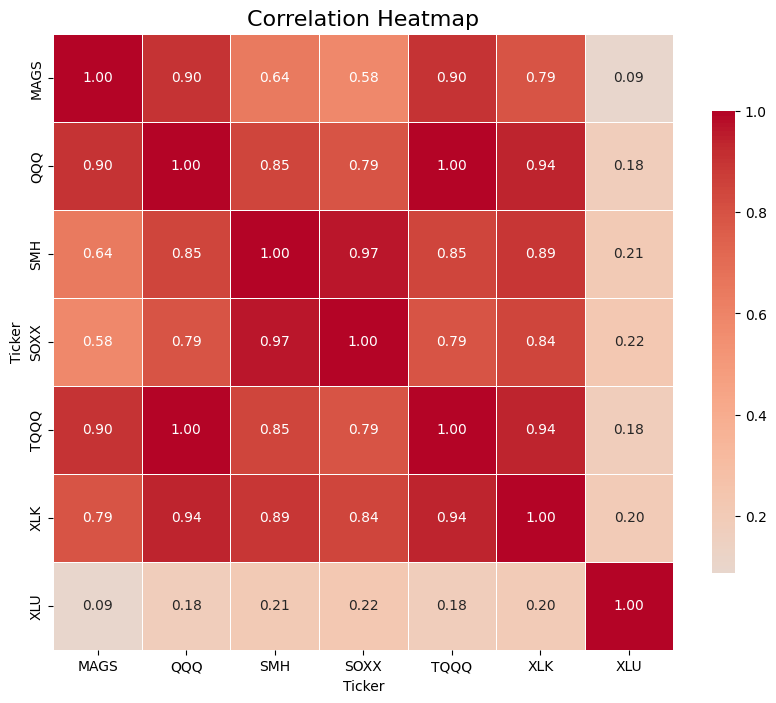

In [15]:

# Example usage
tickers = mrs_1m_df['ETF'].to_list()
ranked_picks = tickers


final_selection, corr_matrix = get_uncorrelated_picks(tickers, ranked_picks, threshold=0.66)

# Step 2: Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Step 3: Draw the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,         # Show correlation values
    fmt=".2f",          # Format to 2 decimal places
    cmap="coolwarm",    # Color map
    center=0,           # Center the colormap at 0
    linewidths=0.5,     # Lines between cells
    cbar_kws={"shrink": 0.75}  # Shrink color bar
)

# Step 4: Add title and show
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [16]:
final_selection

['TQQQ', 'XLU']